Saved: corner_error_analysis.png
Phantom4: 12 experiments
Mavic2: 7 experiments


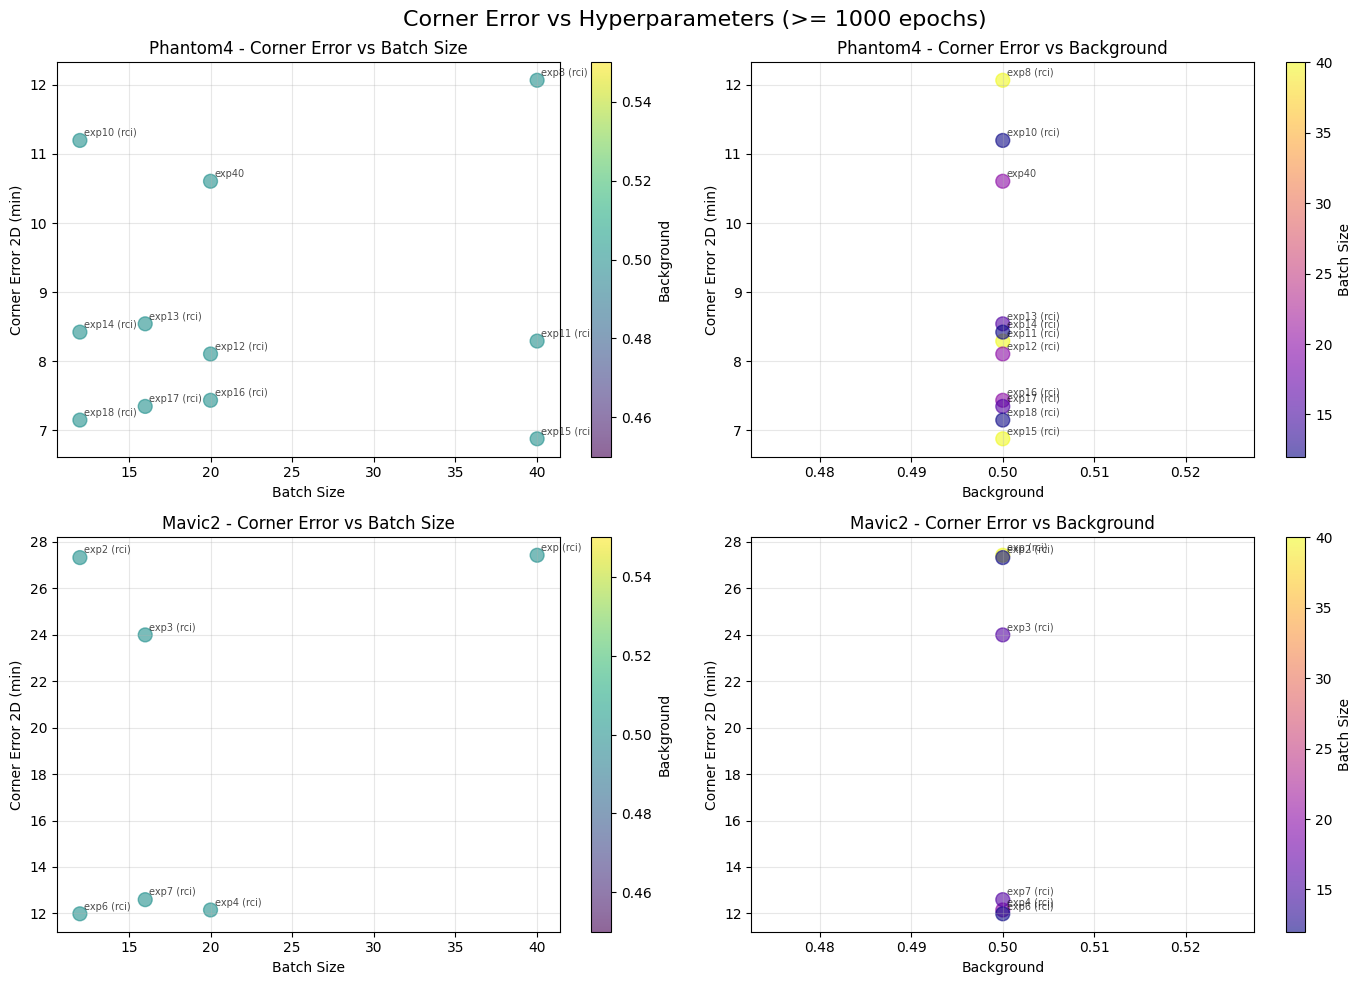

In [3]:
# TRAINING HYPERPARAMETER vs CORNER ERROR SCATTER PLOT
#
# PURPOSE:
#   Scan all YOLOv5-6D-Pose training runs (local + RCI cluster), extract
#   best validation corner error from TensorBoard logs, and plot it against
#   batch size and background augmentation probability — separated by dataset.
#
# INPUT:
#   RUNS_DIRS/ (one or more)
#     exp*/
#       hyp.yaml         — hyperparameters (background augmentation prob)
#       opt.yaml          — options (batch_size, data path → dataset name)
#       events.out.tfevents.*  — TensorBoard logs
#
#   Expected TensorBoard scalars:
#     train/box_loss           — used to count epochs (must have >= MIN_EPOCHS)
#     val/mean_corner_err_2d   — validation metric; min value extracted
#
# DOES:
#   - Iterates all exp* dirs across RUNS_DIRS (local Desktop + RCI cluster)
#   - From hyp.yaml: reads background augmentation probability
#   - From opt.yaml: reads batch_size; infers dataset name from data path
#   - From TensorBoard: counts epochs, extracts min(val/mean_corner_err_2d)
#   - Filters out runs with < MIN_EPOCHS (1000) or missing metrics
#   - Splits results by dataset (phantom4 / mavic2)
#   - Plots 2×2 grid:
#       (row=dataset, col=0): corner_err vs batch_size, colored by background
#       (row=dataset, col=1): corner_err vs background, colored by batch_size
#     Each point labeled with experiment name (+ "rci" tag if from cluster)
#
# OUTPUT:
#   corner_error_analysis.png — 2×2 scatter plot
#   Console: experiment counts per dataset
#
# DEPENDENCIES:
#   yaml, numpy, matplotlib, tensorboard (event_accumulator)

import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator

# ============================================================================
# CONFIG
# ============================================================================

RUNS_DIRS = [
    Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train',
    Path.home() / 'rci_cluster/YOLOv5-6D-Pose/runs/train',
]

MIN_EPOCHS = 1000

# ============================================================================
# EXTRACT
# ============================================================================

def extract_experiment(exp_dir, source_path):
    data = {'exp': exp_dir.name, 'dataset': None, 'background': None, 'batch_size': None}
    
    # Track source
    data['from_rci'] = 'rci_cluster' in str(source_path)
    
    # Read hyperparameters
    hyp_file = exp_dir / 'hyp.yaml'
    if hyp_file.exists():
        with open(hyp_file) as f:
            hyp = yaml.safe_load(f)
            data['background'] = hyp.get('background')
    
    opt_file = exp_dir / 'opt.yaml'
    if opt_file.exists():
        with open(opt_file) as f:
            opt = yaml.safe_load(f)
            data['batch_size'] = opt.get('batch_size')
            data_path = str(opt.get('data', '')).lower()
            if 'phantom4' in data_path:
                data['dataset'] = 'phantom4'
            elif 'mavic2' in data_path:
                data['dataset'] = 'mavic2'
    
    # Read TensorBoard
    try:
        ea = event_accumulator.EventAccumulator(str(exp_dir))
        ea.Reload()
        
        # Check number of epochs
        if 'train/box_loss' in ea.Tags().get('scalars', []):
            train_events = ea.Scalars('train/box_loss')
            data['num_epochs'] = len(train_events)
            
            if data['num_epochs'] < MIN_EPOCHS:
                return None
        else:
            return None
        
        # Extract corner error
        if 'val/mean_corner_err_2d' in ea.Tags().get('scalars', []):
            events = ea.Scalars('val/mean_corner_err_2d')
            values = [e.value for e in events]
            data['corner_err_min'] = min(values)
        else:
            return None
            
    except:
        return None
    
    return data

# ============================================================================
# MAIN
# ============================================================================

all_data = []

for runs_dir in RUNS_DIRS:
    if not runs_dir.exists():
        continue
    
    for exp_dir in sorted(runs_dir.glob('exp*')):
        if exp_dir.is_dir():
            data = extract_experiment(exp_dir, runs_dir)
            if data and data.get('dataset') and data.get('corner_err_min') is not None:
                all_data.append(data)

# Separate by dataset
phantom4_data = [d for d in all_data if d['dataset'] == 'phantom4']
mavic2_data = [d for d in all_data if d['dataset'] == 'mavic2']

# ============================================================================
# PLOT
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Corner Error vs Hyperparameters (>= {MIN_EPOCHS} epochs)', fontsize=16)

for idx, (dataset_data, dataset_name) in enumerate([(phantom4_data, 'Phantom4'), 
                                                      (mavic2_data, 'Mavic2')]):
    if not dataset_data:
        for col in range(2):
            axes[idx, col].text(0.5, 0.5, f'No {dataset_name} data', 
                               ha='center', va='center', transform=axes[idx, col].transAxes)
            axes[idx, col].set_xticks([])
            axes[idx, col].set_yticks([])
        continue
    
    # Extract arrays
    backgrounds = np.array([d['background'] for d in dataset_data])
    batch_sizes = np.array([d['batch_size'] for d in dataset_data])
    corner_err = np.array([d['corner_err_min'] for d in dataset_data])
    
    # Plot 1: Corner Error vs Batch Size
    ax = axes[idx, 0]
    sc = ax.scatter(batch_sizes, corner_err, s=100, alpha=0.6, c=backgrounds, cmap='viridis')
    ax.set_xlabel('Batch Size')
    ax.set_ylabel('Corner Error 2D (min)')
    ax.set_title(f'{dataset_name} - Corner Error vs Batch Size')
    ax.grid(True, alpha=0.3)
    
    # Add labels
    for d in dataset_data:
        label = d['exp']
        if d['from_rci']:
            label += ' (rci)'
        ax.annotate(label, (d['batch_size'], d['corner_err_min']), 
                   fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')
    
    plt.colorbar(sc, ax=ax, label='Background')
    
    # Plot 2: Corner Error vs Background
    ax = axes[idx, 1]
    sc = ax.scatter(backgrounds, corner_err, s=100, alpha=0.6, c=batch_sizes, cmap='plasma')
    ax.set_xlabel('Background')
    ax.set_ylabel('Corner Error 2D (min)')
    ax.set_title(f'{dataset_name} - Corner Error vs Background')
    ax.grid(True, alpha=0.3)
    
    # Add labels
    for d in dataset_data:
        label = d['exp']
        if d['from_rci']:
            label += ' (rci)'
        ax.annotate(label, (d['background'], d['corner_err_min']), 
                   fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')
    
    plt.colorbar(sc, ax=ax, label='Batch Size')

plt.tight_layout()
plt.savefig('corner_error_analysis.png', dpi=150, bbox_inches='tight')
print(f"Saved: corner_error_analysis.png")
print(f"Phantom4: {len(phantom4_data)} experiments")
print(f"Mavic2: {len(mavic2_data)} experiments")

In [1]:
# YOLO6D PREDICTION vs GT CORNER ERROR ANALYSIS (test.py-COMPATIBLE COORDINATES)
#
# PURPOSE:
#   Run YOLOv5-6D inference on a small slice of the validation set, compute
#   per-corner x/y prediction errors against ground truth (using the exact
#   same coordinate handling as test.py), and visualize a few sample frames
#   with GT (green) and predicted (red) 3D bounding box overlays.
#
# PIPELINE (per frame):
#   image → letterbox → YOLOv5-6D → 9 keypoints → scale_coords → pred in original pixels
#   label → normalized coords × unpadded dims + pad → scale_coords → GT in original pixels
#   error = pred - GT per corner, split into x and y components
#
# DATA STRUCTURES:
#   pred_pixels:  (9, 2) float — predicted [centroid, corner1..8] in original image pixels
#   gt_pixels:    (9, 2) float — GT corners, same layout
#   errors_x/y:   flat lists of per-corner x/y signed errors (centroid excluded)
#   edges:        12 × [i, j] — 3D bbox wireframe topology (0-based into 8 corners)
#   label format: class x0 y0 x1 y1 ... x8 y8 [extra]
#                 indices 1–18 = centroid + 8 corners, normalized to unpadded image area
#
# INPUT DIRECTORY LAYOUT (EXPECTED):
#   DATA_DIR/
#     JPEGImages/*.jpg    — all images (train + val, sorted)
#     labels/*.txt        — YOLO6D labels (one per image)
#   WEIGHTS: exp40/weights/best.pt
#   Test slice: images from START_PCT (90%) to END_PCT (90.2%) of sorted file list
#
# DOES:
#   - Loads model, selects a narrow slice of images (~0.2% of dataset)
#   - Per frame: inference → scale pred + GT to original image space
#   - Collects signed x/y errors for all 8 corners (centroid excluded)
#   - Reports: mean, median, min, max, std for x and y errors separately
#   - Reports spatial extent of GT corners (min/max x, y)
#   - Saves overlay visualization of first NUM_VIZ frames to test_viz.png
#     (GT = green solid + lime dots, pred = red solid + red crosses)
#
# OUTPUT:
#   test_viz.png — annotated overlay of sample frames
#   Console: signed error statistics (x and y separately), spatial coverage
#
# DEPENDENCIES:
#   numpy, opencv, torch, matplotlib, tqdm
#   YOLOv5-6D-Pose repo (models.experimental, utils.{datasets,general,pose_utils,torch_utils})
#
# NOTES:
#   - Errors are SIGNED (pred - GT), not absolute — useful for detecting systematic bias.
#   - Coordinate handling matches test.py exactly: labels normalized to unpadded letterbox
#     area, then offset by pad, then scale_coords back to original image space.
#   - Centroid (index 0) excluded from error computation.
#   - conf_thres=0.01 with highest-confidence detection selected per frame.

import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import sys
import cv2
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))

from models.experimental import attempt_load
from utils.general import check_img_size, scale_coords
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.pose_utils import box_filter

# ============================================================================
# CONFIG
# ============================================================================

WEIGHTS = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train/exp4/weights/best.pt')
DATA_DIR = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/data/Shiu/mavic2')

START_PCT = 0.9
END_PCT = 0.902

IMG_SIZE = 640
DEVICE = 'cpu'
NUM_VIZ = 5

# ============================================================================
# MAIN
# ============================================================================

print("Testing model...")

device = select_device(DEVICE)
model = attempt_load(WEIGHTS, map_location=device)
stride = int(model.stride.max())
img_size = check_img_size(IMG_SIZE, s=stride)
model.eval()

data_dir = Path(DATA_DIR)
images_dir = data_dir / 'JPEGImages'
labels_dir = data_dir / 'labels'

image_files = sorted(list(images_dir.glob('*.jpg')))
start_idx = int(len(image_files) * START_PCT)
end_idx = int(len(image_files) * END_PCT)
test_images = image_files[start_idx:end_idx]

print(f"Testing {len(test_images)} images")

edges = [[0,1],[0,2],[0,4],[1,3],[1,5],[2,3],[2,6],[3,7],[4,5],[4,6],[5,7],[6,7]]
errors_x = []
errors_y = []
xs = []
ys = []
viz_data = []

for img_path in tqdm(test_images):
    label_path = labels_dir / f"{img_path.stem}.txt"
    if not label_path.exists():
        continue
    
    # Read label
    with open(label_path) as f:
        label_data = [float(x) for x in f.readline().strip().split()]
    
    if len(label_data) < 21:
        continue
    
    # Load image
    img0 = cv2.imread(str(img_path))
    if img0 is None:
        continue
    
    h0, w0 = img0.shape[:2]
    
    # Letterbox (matching test.py)
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shape = (h0, w0)  # original shape
    shapes = ((h0, w0), (ratio, pad))  # for scale_coords
    
    # To tensor
    img_tensor = img[:, :, ::-1].transpose(2, 0, 1)
    img_tensor = np.ascontiguousarray(img_tensor)
    img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
    if img_tensor.ndimension() == 3:
        img_tensor = img_tensor.unsqueeze(0)
    
    # Inference
    with torch.no_grad():
        pred, _ = model(img_tensor)
    
    # Filter by confidence threshold (CRITICAL!)
    pred = box_filter(pred, conf_thres=0.01, max_det=10)  # Allow up to 10 detections
    
    if pred is None or len(pred) == 0 or len(pred[0]) == 0:
        continue
    
    # Get the detection that matches this ground truth
    # For now, use the highest confidence one
    det = pred[0][0].clone().cpu()
    corners_pred = det[:18].reshape(1, 18)
    
    # Scale predictions to native space
    scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
    pred_pixels = corners_pred[0].numpy().reshape(9, 2)
    
    # Get GT - matching test.py EXACTLY
    # Labels indices 1-18 are centroid + 8 corners (normalized 0-1)
    gt_norm = np.array([label_data[i] for i in range(1, 19)])
    
    # In test.py: nb, _, height, width = img.shape (tensor shape)
    _, _, height, width = img_tensor.shape
    
    # IMPORTANT: The letterbox might have padding!
    # We need to multiply by the ACTUAL image dimensions in the letterbox, not the padded dimensions
    # Unpadded dimensions:
    unpadded_w = width - 2 * pad[0]
    unpadded_h = height - 2 * pad[1]
    
    #print(f"\nDEBUG dimensions:")
    #print(f"  Letterbox (w, h): ({width}, {height})")
    #print(f"  Padding (x, y): {pad}")
    #print(f"  Unpadded (w, h): ({unpadded_w}, {unpadded_h})")

    gt_letterbox = gt_norm.copy()
    gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w  # x coords  
    gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h  # y coords
    
    # Now add the padding offset
    gt_letterbox[::2] += pad[0]  # x offset
    gt_letterbox[1::2] += pad[1]  # y offset
    
    # Scale to native space - CRITICAL: pass shapes[1] which is (ratio, pad)!
    gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
    
    #print(f"\nDEBUG GT scaling:")
    #print(f"  Before scale_coords: {gt_letterbox_tensor[0, :6].numpy()}")
    #print(f"  shapes[1] = {shapes[1]}")
    #print(f"  ratio = {shapes[1][0]}, pad = {shapes[1][1]}")
    
    scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])
    
    #print(f"  After scale_coords: {gt_letterbox_tensor[0, :6].numpy()}")
    
    gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)
    #print(f"  Final GT pixels (first point): {gt_pixels[0]}")
    
    # Compute error (skip centroid at index 0)
    for i in range(1, 9):
        error_x = pred_pixels[i, 0] - gt_pixels[i, 0]
        error_y = pred_pixels[i, 1] - gt_pixels[i, 1]
        errors_x.append(error_x)
        errors_y.append(error_y)
        xs.append(gt_pixels[i, 0])
        ys.append(gt_pixels[i, 1])

    # Store for viz
    if len(viz_data) < NUM_VIZ:
        viz_data.append({
            'img': img0,
            'pred': pred_pixels,
            'gt': gt_pixels,
            'name': img_path.name
        })

# Results
errors_x = np.array(errors_x)
errors_y = np.array(errors_y)
print(f"\n{'='*80}")
print("RESULTS")
print(f"{'='*80}")
print(f"Tested: {len(errors_x)}")
print(f"Mean error (x):   {np.mean(errors_x):.2f} px")
print(f"Median error (x): {np.median(errors_x):.2f} px")
print(f"Min error (x):    {np.min(errors_x):.2f} px")
print(f"Max error (x):    {np.max(errors_x):.2f} px")
print(f"{'='*80}\n")

# mean and std for x errors
print(f"Mean error (x):   {np.mean(errors_x):.2f} px")
print(f"Median error (x): {np.median(errors_x):.2f} px")
print(f"Min error (x):    {np.min(errors_x):.2f} px")
print(f"Max error (x):    {np.max(errors_x):.2f} px")
print(f"{'='*80}\n")
# also std with and without mean error subtraction
print(f"Std error (x):    {np.sqrt(np.mean((errors_x - np.mean(errors_x))**2)):.2f} px")
print(f"Std error (x, mean subtracted): {np.sqrt(np.mean((errors_x - np.mean(errors_x))**2)):.2f} px")

# mean and std for y errors
print(f"Mean error (y):   {np.mean(errors_y):.2f} px")
print(f"Median error (y): {np.median(errors_y):.2f} px")
print(f"Min error (y):    {np.min(errors_y):.2f} px")
print(f"Max error (y):    {np.max(errors_y):.2f} px")
#also std with and without mean error subtraction
print(f"Std error (y):    {np.sqrt(np.mean((errors_y - np.mean(errors_y))**2)):.2f} px")
print(f"Std error (y, mean subtracted): {np.sqrt(np.mean((errors_y - np.mean(errors_y))**2)):.2f} px")

#max and min x and y vals
print(f"Min x: {np.min(xs):.2f} px")
print(f"Max x: {np.max(xs):.2f} px")
print(f"Min y: {np.min(ys):.2f} px")
print(f"Max y: {np.max(ys):.2f} px")

if NUM_VIZ == 1:
    axes = [axes]

for idx, data in enumerate(viz_data):
    ax = axes[idx]
    img_rgb = cv2.cvtColor(data['img'], cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    
    gt = data['gt']
    pred = data['pred']
    
    # Draw GT (green)
    for i, edge in enumerate(edges):
        ax.plot([gt[edge[0]+1, 0], gt[edge[1]+1, 0]], 
                [gt[edge[0]+1, 1], gt[edge[1]+1, 1]], 
                'g-', linewidth=2, label='GT' if i==0 else '')
    ax.scatter(gt[1:, 0], gt[1:, 1], c='lime', s=50, edgecolors='white', linewidths=1)
    ax.scatter(gt[0, 0], gt[0, 1], c='lime', s=100, marker='*', edgecolors='black', linewidths=2)
    
    # Draw Pred (red)
    for i, edge in enumerate(edges):
        ax.plot([pred[edge[0]+1, 0], pred[edge[1]+1, 0]], 
                [pred[edge[0]+1, 1], pred[edge[1]+1, 1]], 
                'r-', linewidth=2, label='Pred' if i==0 else '')
    ax.scatter(pred[1:, 0], pred[1:, 1], c='red', s=50, marker='x', linewidths=2)
    ax.scatter(pred[0, 0], pred[0, 1], c='orange', s=100, marker='*', linewidths=2)
    
    ax.set_title(f"{data['name']} - Error: {data['error']:.2f}px")
    ax.legend()
    ax.axis('off')

plt.tight_layout()
plt.savefig('test_viz.png', dpi=150, bbox_inches='tight')
print("Saved: test_viz.png")

/home/michal/git/YOLOv5-6D-Pose/utils/general.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


Testing model...


/home/michal/anaconda3/envs/yolo6d/lib/python3.9/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4314.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Testing 34 images


100%|██████████| 34/34 [01:23<00:00,  2.46s/it]



RESULTS
Tested: 272
Mean error (x):   1.23 px
Median error (x): 0.39 px
Min error (x):    -18.03 px
Max error (x):    19.83 px

Mean error (x):   1.23 px
Median error (x): 0.39 px
Min error (x):    -18.03 px
Max error (x):    19.83 px

Std error (x):    6.48 px
Std error (x, mean subtracted): 6.48 px
Mean error (y):   -1.19 px
Median error (y): -1.56 px
Min error (y):    -13.49 px
Max error (y):    11.56 px
Std error (y):    4.34 px
Std error (y, mean subtracted): 4.34 px
Min x: 204.78 px
Max x: 1385.70 px
Min y: 481.50 px
Max y: 616.66 px


NameError: name 'axes' is not defined

In [4]:
# YOLO6D SINGLE-IMAGE PREDICTION + PnP 6D POSE ESTIMATION UTILITIES
#
# PURPOSE:
#   Two reusable functions for the YOLOv5-6D pipeline:
#     1. predict()         — run inference on one image, return pred + GT corners in pixels
#     2. estimate_6d_pose() — solve PnP from 2D corners → rotation + translation
#
# FUNCTION: predict(model, image_path, label_path, ...)
#   Pipeline:
#     image → letterbox resize → YOLOv5-6D inference → top detection → scale to original pixels
#     label → parse normalized coords → undo letterbox → scale to original pixels
#   Returns: pred_corners (9,2), gt_corners (9,2), confidence, mean corner error (px), image
#
#   Label format (labels_yolo6d):
#     class x0 y0 x1 y1 ... x8 y8 [bbox_x bbox_y bbox_w bbox_h]
#     indices 1–18 = centroid + 8 corners, normalized to unpadded image area
#     Minimum 21 values expected (class + 18 keypoint coords + bbox)
#
# FUNCTION: estimate_6d_pose(corners_2d, camera_matrix, dist_coeffs, object_points_3d)
#   Pipeline:
#     8 corners (skip centroid) → cv2.solvePnP (ITERATIVE) → rvec, tvec
#     → Rodrigues → rotation matrix + reprojection error
#   Returns: rotation_matrix (3×3), translation_vector (3×1), rvec, tvec, reproj error
#
#   Default 3D model: Phantom 4 bounding box
#     x: [-0.18, 0.16], y: [-0.16, 0.18], z: [-0.17, 0.06] meters
#     9 points: centroid + 8 axis-aligned corners (same order as labels)
#
# DATA STRUCTURES:
#   corners_2d:       (9, 2) float — [centroid, corner1..corner8] in image pixels
#   object_points_3d: (9, 3) float — matching 3D points in body frame (meters)
#   camera_matrix:    (3, 3) float — intrinsic K
#   dist_coeffs:      (5,) or (8,) float — OpenCV distortion [k1,k2,p1,p2,k3,...]
#
# DEPENDENCIES:
#   torch, numpy, opencv
#   YOLOv5-6D-Pose repo (utils.datasets, utils.general, utils.pose_utils)
#
# NOTES:
#   - predict() uses labels_yolo6d format (normalized to unpadded letterbox area)
#   - PnP uses 8 corners only (centroid skipped for stability)
#   - Reprojection error computed on the 8 corners used for PnP
#   - Corner error in predict() is mean L2 over 8 corners (centroid excluded)

import torch
import numpy as np
import cv2
from pathlib import Path

def predict(model, image_path, label_path, img_size=640, conf_thresh=0.01, device='cpu'):
    """
    Get pose prediction for a single image.
    
    Args:
        model: Loaded YOLOv5-6D model
        image_path: Path to input image
        label_path: Path to label file (for ground truth)
        img_size: Input size for model (default: 640)
        conf_thresh: Confidence threshold for detections (default: 0.01)
        device: Device to run inference on ('cpu' or 'cuda')
    
    Returns:
        dict with keys:
            'pred_corners': Predicted corners in original image space (9x2 array)
            'gt_corners': Ground truth corners in original image space (9x2 array)
            'confidence': Prediction confidence score
            'error': Mean corner error in pixels (excluding centroid)
            'image': Original image (BGR format)
            'success': Boolean indicating if prediction was successful
    """
    from utils.datasets import letterbox
    from utils.general import check_img_size, scale_coords
    from utils.pose_utils import box_filter
    
    # Load image
    img0 = cv2.imread(str(image_path))
    if img0 is None:
        return {'success': False, 'error_msg': 'Failed to load image'}
    
    h0, w0 = img0.shape[:2]
    
    # Load label (expect 21+ values: class, centroid, 8 corners)
    try:
        with open(label_path) as f:
            label_data = [float(x) for x in f.readline().strip().split()]
        if len(label_data) < 21:
            return {'success': False, 'error_msg': f'Label has only {len(label_data)} values, need at least 21'}
    except Exception as e:
        return {'success': False, 'error_msg': f'Failed to load label: {e}'}
    
    # Prepare image for inference
    stride = int(model.stride.max())
    img_size = check_img_size(img_size, s=stride)
    
    # Letterbox resize
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shape = (h0, w0)
    shapes = ((h0, w0), (ratio, pad))
    
    # Convert to tensor
    img_tensor = img[:, :, ::-1].transpose(2, 0, 1)  # BGR to RGB, HWC to CHW
    img_tensor = np.ascontiguousarray(img_tensor)
    img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
    if img_tensor.ndimension() == 3:
        img_tensor = img_tensor.unsqueeze(0)  # Add batch dimension
    
    # Run inference
    with torch.no_grad():
        pred, _ = model(img_tensor)
    
    # Filter by confidence threshold
    pred = box_filter(pred, conf_thres=conf_thresh, max_det=10)
    
    if pred is None or len(pred) == 0 or len(pred[0]) == 0:
        return {'success': False, 'error_msg': 'No detections above confidence threshold'}

    # Get highest confidence detection
    det = pred[0][0].clone().cpu()
    confidence = float(det[18])
    corners_pred = det[:18].reshape(1, 18)
    
    # Scale predictions to original image space
    scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
    pred_pixels = corners_pred[0].numpy().reshape(9, 2)
    
    # Process ground truth
    # Label format: [class, x0, y0, x1, y1, ..., x8, y8, ...]
    # Indices 1-18 contain centroid + 8 corners (normalized 0-1)
    gt_norm = np.array([label_data[i] for i in range(1, 19)])
    
    # Get letterbox dimensions
    _, _, height, width = img_tensor.shape
    
    # CRITICAL: Labels are normalized to unpadded image area
    unpadded_w = width - 2 * pad[0]
    unpadded_h = height - 2 * pad[1]
    
    # Convert GT to letterbox pixels
    gt_letterbox = gt_norm.copy()
    gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w + pad[0]  # x coords
    gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h + pad[1]  # y coords
    
    # Scale GT to original image space
    gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
    scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])
    gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)
    
    # Compute error (skip centroid at index 0)
    corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))
    
    return {
        'success': True,
        'pred_corners': pred_pixels,
        'gt_corners': gt_pixels,
        'confidence': confidence,
        'error': corner_error,
        'image': img0
    }

"""
PnP Pose Estimation for YOLOv5-6D
Estimates 6D pose (rotation + translation) from 2D corner predictions
"""

import numpy as np
import cv2


def estimate_6d_pose(corners_2d, camera_matrix, dist_coeffs=None, object_points_3d=None):
    """
    Estimate 6D pose (rotation and translation) from 2D corner predictions using PnP.
    
    Args:
        corners_2d: Predicted 2D corners in image space (9x2 numpy array)
                   Format: [centroid, corner1, corner2, ..., corner8]
        camera_matrix: Camera intrinsic matrix (3x3 numpy array)
                      [[fx,  0, cx],
                       [ 0, fy, cy],
                       [ 0,  0,  1]]
        dist_coeffs: Distortion coefficients (5,) or (8,) numpy array (optional)
                    Format: [k1, k2, p1, p2, k3] or [k1, k2, p1, p2, k3, k4, k5, k6]
                    If None, assumes no distortion
        object_points_3d: 3D object points in object coordinate frame (9x3 numpy array)
                         Format: [centroid, corner1, corner2, ..., corner8]
                         If None, uses default Phantom 4 drone 3D model
    
    Returns:
        dict with keys:
            'success': Boolean indicating if pose estimation succeeded
            'rotation_matrix': 3x3 rotation matrix (camera frame ← object frame)
            'translation_vector': 3x1 translation vector (in meters)
            'rvec': 3x1 rotation vector (Rodrigues format)
            'tvec': 3x1 translation vector (same as translation_vector)
            'reprojection_error': Mean reprojection error in pixels
            
            If failed:
            'error_msg': Error message
    """
    
    # Default Phantom 4 3D model (in meters)
    if object_points_3d is None:
        # Bounding box dimensions
        # min_x, max_x = -0.18, 0.16
        # min_y, max_y = -0.16, 0.18
        # min_z, max_z = -0.17, 0.06

        min_x, max_x = -0.22503, 0.05875
        min_y, max_y = -0.16151, 0.17152
        min_z, max_z = -0.10000, 0.02000   
        
        object_points_3d = np.array([
            [(min_x + max_x) / 2, (min_y + max_y) / 2, (min_z + max_z) / 2],  # centroid
            [min_x, min_y, min_z],  # corner 1
            [min_x, min_y, max_z],  # corner 2
            [min_x, max_y, min_z],  # corner 3
            [min_x, max_y, max_z],  # corner 4
            [max_x, min_y, min_z],  # corner 5
            [max_x, min_y, max_z],  # corner 6
            [max_x, max_y, min_z],  # corner 7
            [max_x, max_y, max_z],  # corner 8
        ], dtype=np.float32)
    
    # Default: no distortion
    if dist_coeffs is None:
        dist_coeffs = np.zeros(5, dtype=np.float32)
    
    # Validate inputs
    if corners_2d.shape[0] != 9 or corners_2d.shape[1] != 2:
        return {
            'success': False,
            'error_msg': f'corners_2d must be 9x2, got {corners_2d.shape}'
        }
    
    if object_points_3d.shape[0] != 9 or object_points_3d.shape[1] != 3:
        return {
            'success': False,
            'error_msg': f'object_points_3d must be 9x3, got {object_points_3d.shape}'
        }
    
    if camera_matrix.shape != (3, 3):
        return {
            'success': False,
            'error_msg': f'camera_matrix must be 3x3, got {camera_matrix.shape}'
        }
    
    try:
        # PnP expects: (N, 3) object points, (N, 2) image points
        # Skip centroid (index 0) - use only the 8 corners for more stable estimation
        obj_pts = object_points_3d[1:, :].astype(np.float32)  # 8x3
        img_pts = corners_2d[1:, :].astype(np.float32)  # 8x2
        
        # Solve PnP using ITERATIVE method (good for initial estimate)
        success, rvec, tvec = cv2.solvePnP(
            obj_pts, 
            img_pts, 
            camera_matrix, 
            dist_coeffs,
            flags=cv2.SOLVEPNP_ITERATIVE
        )
        
        if not success:
            return {
                'success': False,
                'error_msg': 'cv2.solvePnP returned failure'
            }
        
        # Convert rotation vector to rotation matrix
        rotation_matrix, _ = cv2.Rodrigues(rvec)
        
        # Compute reprojection error
        projected_pts, _ = cv2.projectPoints(
            obj_pts, 
            rvec, 
            tvec, 
            camera_matrix, 
            dist_coeffs
        )
        projected_pts = projected_pts.reshape(-1, 2)
        reprojection_error = np.mean(np.linalg.norm(projected_pts - img_pts, axis=1))
        
        return {
            'success': True,
            'rotation_matrix': rotation_matrix,
            'translation_vector': tvec.reshape(3, 1),
            'rvec': rvec,
            'tvec': tvec,
            'reprojection_error': reprojection_error
        }
        
    except Exception as e:
        return {
            'success': False,
            'error_msg': f'Exception during PnP: {str(e)}'
        }


# Example usage
if __name__ == '__main__':
    # Example: Phantom 4 drone
    
    # Camera intrinsics (from the provided file)
    fx, fy, cx, cy = 1979.4, 1979.1, 976.8189, 533.9717
    camera_matrix = np.array([
        [fx,  0, cx],
        [ 0, fy, cy],
        [ 0,  0,  1]
    ], dtype=np.float32)
    
    # Distortion coefficients (from the provided file)
    dist_coeffs = np.array([-0.2306, 0.1497, -0.00089582, -0.00086321, -0.0522086113480487], 
                          dtype=np.float32)
    
    # Example predicted 2D corners (9x2: centroid + 8 corners)
    corners_2d = np.array([
        [960, 540],   # centroid
        [800, 400],   # corner 1
        [800, 450],   # corner 2
        [800, 600],   # corner 3
        [800, 650],   # corner 4
        [1120, 400],  # corner 5
        [1120, 450],  # corner 6
        [1120, 600],  # corner 7
        [1120, 650],  # corner 8
    ], dtype=np.float32)
    
    # Estimate pose
    result = estimate_6d_pose(corners_2d, camera_matrix, dist_coeffs)
    
    if result['success']:
        print("✓ Pose estimation successful!")
        print(f"\nRotation matrix (camera ← object):")
        print(result['rotation_matrix'])
        print(f"\nTranslation vector (meters):")
        print(result['translation_vector'].T)
        print(f"\nReprojection error: {result['reprojection_error']:.2f} pixels")
    else:
        print(f"✗ Pose estimation failed: {result['error_msg']}")
# Example usage
if __name__ == '__main__':
    import sys
    from pathlib import Path
    
    # Setup paths
    sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))
    
    from models.experimental import attempt_load
    from utils.torch_utils import select_device
    
    # Load model
    WEIGHTS = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train/exp4/weights/best.pt')
    device = select_device('cpu')
    model = attempt_load(WEIGHTS, map_location=device)
    model.eval()
    
    # Test on single image
    DATA_DIR = Path.home() / 'Desktop/YOLOv5-6D-Pose/data/Shiu/mavic2'
    image_path = DATA_DIR / 'JPEGImages' / '00000.jpg'
    label_path = DATA_DIR / 'labels' / '00000.txt'
    
    result = predict(model, image_path, label_path, device=device)
    
    if result['success']:
        print(f"Prediction successful!")
        print(f"Confidence: {result['confidence']:.3f}")
        print(f"Corner error: {result['error']:.2f} pixels")
        print(f"Predicted centroid: {result['pred_corners'][0]}")
        print(f"GT centroid: {result['gt_corners'][0]}")
    else:
        print(f"Prediction failed: {result['error_msg']}")

✓ Pose estimation successful!

Rotation matrix (camera ← object):
[[    0.99996   0.0066158   -0.005387]
 [-2.0517e-05     0.63328     0.77393]
 [  0.0085316     -0.7739     0.63325]]

Translation vector (meters):
[[   0.066533    0.012954      1.9599]]

Reprojection error: 28.59 pixels
Prediction successful!
Confidence: 0.807
Corner error: 7.79 pixels
Predicted centroid: [     982.31      644.46]
GT centroid: [      986.4      645.54]


In [5]:
# PnP 6D POSE ESTIMATOR FROM 2D CORNER PREDICTIONS
#
# PURPOSE:
#   Given 9 predicted 2D keypoints (centroid + 8 bounding box corners) and
#   camera intrinsics, solve Perspective-n-Point to recover the object's
#   6D pose (3D rotation + 3D translation) in the camera frame.
#
# FUNCTION: estimate_6d_pose(corners_2d, camera_matrix, dist_coeffs, object_points_3d)
#
# PIPELINE:
#   corners_2d (9×2 pixels) → drop centroid → 8 corner pairs
#     → cv2.solvePnP (ITERATIVE) → rvec, tvec
#       → cv2.Rodrigues → rotation_matrix (3×3)
#       → cv2.projectPoints → reprojection error (mean L2 over 8 corners)
#
# INPUTS:
#   corners_2d:       (9, 2) float — [centroid, corner1..corner8] in image pixels
#   camera_matrix:    (3, 3) float — intrinsic K  [[fx,0,cx],[0,fy,cy],[0,0,1]]
#   dist_coeffs:      (5,) or (8,) float — [k1,k2,p1,p2,k3,...] (None → zero distortion)
#   object_points_3d: (9, 3) float — 3D model in body frame (None → Phantom 4 default)
#
#   Default 3D model (Phantom 4):
#     x: [-0.18, 0.16], y: [-0.16, 0.18], z: [-0.17, 0.06] meters
#     9 points: centroid (midpoint) + 8 axis-aligned box corners
#     Corner order: (−−−), (−−+), (−+−), (−++), (+−−), (+−+), (++−), (+++)
#
# RETURNS:
#   dict:
#     success, rotation_matrix (3×3), translation_vector (3×1, meters),
#     rvec (Rodrigues), tvec, reprojection_error (pixels)
#     On failure: success=False, error_msg
#
# NOTES:
#   - Centroid (index 0) is skipped for PnP — only 8 corners used for stability.
#   - Reprojection error is mean L2 over the 8 corners.
#   - Input validation: checks shapes of corners (9×2), model (9×3), K (3×3).
#
# DEPENDENCIES:
#   numpy, opencv (cv2.solvePnP, cv2.Rodrigues, cv2.projectPoints)


import numpy as np
import cv2


def estimate_6d_pose(corners_2d, camera_matrix, dist_coeffs=None, object_points_3d=None):
    """
    Estimate 6D pose (rotation and translation) from 2D corner predictions using PnP.
    
    Args:
        corners_2d: Predicted 2D corners in image space (9x2 numpy array)
                   Format: [centroid, corner1, corner2, ..., corner8]
        camera_matrix: Camera intrinsic matrix (3x3 numpy array)
                      [[fx,  0, cx],
                       [ 0, fy, cy],
                       [ 0,  0,  1]]
        dist_coeffs: Distortion coefficients (5,) or (8,) numpy array (optional)
                    Format: [k1, k2, p1, p2, k3] or [k1, k2, p1, p2, k3, k4, k5, k6]
                    If None, assumes no distortion
        object_points_3d: 3D object points in object coordinate frame (9x3 numpy array)
                         Format: [centroid, corner1, corner2, ..., corner8]
                         If None, uses default Phantom 4 drone 3D model
    
    Returns:
        dict with keys:
            'success': Boolean indicating if pose estimation succeeded
            'rotation_matrix': 3x3 rotation matrix (camera frame ← object frame)
            'translation_vector': 3x1 translation vector (in meters)
            'rvec': 3x1 rotation vector (Rodrigues format)
            'tvec': 3x1 translation vector (same as translation_vector)
            'reprojection_error': Mean reprojection error in pixels
            
            If failed:
            'error_msg': Error message
    """
    
    # Default Phantom 4 3D model (in meters)
    if object_points_3d is None:
        # Bounding box dimensions
        min_x, max_x = -0.22503, 0.05875
        min_y, max_y = -0.16151, 0.17152
        min_z, max_z = -0.10000, 0.02000   
        
        object_points_3d = np.array([
            [(min_x + max_x) / 2, (min_y + max_y) / 2, (min_z + max_z) / 2],  # centroid
            [min_x, min_y, min_z],  # corner 1
            [min_x, min_y, max_z],  # corner 2
            [min_x, max_y, min_z],  # corner 3
            [min_x, max_y, max_z],  # corner 4
            [max_x, min_y, min_z],  # corner 5
            [max_x, min_y, max_z],  # corner 6
            [max_x, max_y, min_z],  # corner 7
            [max_x, max_y, max_z],  # corner 8
        ], dtype=np.float32)
    
    # Default: no distortion
    if dist_coeffs is None:
        dist_coeffs = np.zeros(5, dtype=np.float32)
    
    # Validate inputs
    if corners_2d.shape[0] != 9 or corners_2d.shape[1] != 2:
        return {
            'success': False,
            'error_msg': f'corners_2d must be 9x2, got {corners_2d.shape}'
        }
    
    if object_points_3d.shape[0] != 9 or object_points_3d.shape[1] != 3:
        return {
            'success': False,
            'error_msg': f'object_points_3d must be 9x3, got {object_points_3d.shape}'
        }
    
    if camera_matrix.shape != (3, 3):
        return {
            'success': False,
            'error_msg': f'camera_matrix must be 3x3, got {camera_matrix.shape}'
        }
    
    try:
        # PnP expects: (N, 3) object points, (N, 2) image points
        # Skip centroid (index 0) - use only the 8 corners for more stable estimation
        obj_pts = object_points_3d[1:, :].astype(np.float32)  # 8x3
        img_pts = corners_2d[1:, :].astype(np.float32)  # 8x2
        
        # Solve PnP using ITERATIVE method (good for initial estimate)
        success, rvec, tvec = cv2.solvePnP(
            obj_pts, 
            img_pts, 
            camera_matrix, 
            dist_coeffs,
            flags=cv2.SOLVEPNP_ITERATIVE
        )
        
        if not success:
            return {
                'success': False,
                'error_msg': 'cv2.solvePnP returned failure'
            }
        
        # Convert rotation vector to rotation matrix
        rotation_matrix, _ = cv2.Rodrigues(rvec)
        
        # Compute reprojection error
        projected_pts, _ = cv2.projectPoints(
            obj_pts, 
            rvec, 
            tvec, 
            camera_matrix, 
            dist_coeffs
        )
        projected_pts = projected_pts.reshape(-1, 2)
        reprojection_error = np.mean(np.linalg.norm(projected_pts - img_pts, axis=1))
        
        return {
            'success': True,
            'rotation_matrix': rotation_matrix,
            'translation_vector': tvec.reshape(3, 1),
            'rvec': rvec,
            'tvec': tvec,
            'reprojection_error': reprojection_error
        }
        
    except Exception as e:
        return {
            'success': False,
            'error_msg': f'Exception during PnP: {str(e)}'
        }


# Example usage
if __name__ == '__main__':
    # Example: Phantom 4 drone
    
    # Camera intrinsics (from the provided file)
    fx, fy, cx, cy = 1979.4, 1979.1, 976.8189, 533.9717
    camera_matrix = np.array([
        [fx,  0, cx],
        [ 0, fy, cy],
        [ 0,  0,  1]
    ], dtype=np.float32)
    
    # Distortion coefficients (from the provided file)
    dist_coeffs = np.array([-0.2306, 0.1497, -0.00089582, -0.00086321, -0.0522086113480487], 
                          dtype=np.float32)
    
    # Example predicted 2D corners (9x2: centroid + 8 corners)
    corners_2d = np.array([
        [960, 540],   # centroid
        [800, 400],   # corner 1
        [800, 450],   # corner 2
        [800, 600],   # corner 3
        [800, 650],   # corner 4
        [1120, 400],  # corner 5
        [1120, 450],  # corner 6
        [1120, 600],  # corner 7
        [1120, 650],  # corner 8
    ], dtype=np.float32)
    
    # Estimate pose
    result = estimate_6d_pose(corners_2d, camera_matrix, dist_coeffs)
    
    if result['success']:
        print("✓ Pose estimation successful!")
        print(f"\nRotation matrix (camera ← object):")
        print(result['rotation_matrix'])
        print(f"\nTranslation vector (meters):")
        print(result['translation_vector'].T)
        print(f"\nReprojection error: {result['reprojection_error']:.2f} pixels")
    else:
        print(f"✗ Pose estimation failed: {result['error_msg']}")

✓ Pose estimation successful!

Rotation matrix (camera ← object):
[[    0.99996   0.0066158   -0.005387]
 [-2.0517e-05     0.63328     0.77393]
 [  0.0085316     -0.7739     0.63325]]

Translation vector (meters):
[[   0.066533    0.012954      1.9599]]

Reprojection error: 28.59 pixels


In [7]:
# 6D POSE ESTIMATION & DISTORTION-ABLATION TEST HARNESS
#
# PURPOSE:
#   Run YOLOv5-6D-Pose inference on validation images, estimate 6D object pose
#   via PnP, and compare reprojection error WITH vs WITHOUT lens distortion
#   correction to determine if distortion coefficients actually help.
#
# PIPELINE:
#   image → YOLOv5-6D → 9 keypoints (centroid + 8 bbox corners) in pixels
#     → solvePnP(3D model ↔ 2D corners) → rotation + translation → reprojection error
#
# DATA STRUCTURES:
#   corners_2d:       (9, 2) float — [centroid, corner1..corner8] in image pixels
#   object_points_3d: (9, 3) float — matching 3D points in object frame (meters)
#                     Default: Phantom 4 drone bounding box
#                       min/max extents ≈ 0.34 × 0.34 × 0.23 m
#   camera_matrix:    (3, 3) float — intrinsic K  [[fx,0,cx],[0,fy,cy],[0,0,1]]
#   dist_coeffs:      (5,)   float — [k1, k2, p1, p2, k3]  (OpenCV convention)
#   label format:     class  x0 y0  x1 y1 ... x8 y8  (normalized to unpadded image area)
#                     indices 1–18 = centroid + 8 corners, values in [0,1]
#
# DOES:
#   estimate_6d_pose():
#     - Takes 9 predicted 2D keypoints + camera intrinsics
#     - Runs cv2.solvePnP (ITERATIVE) on the 8 corners (drops centroid for stability)
#     - Returns rotation matrix, translation vector, and reprojection error
#
#   predict():
#     - Loads image + ground-truth label
#     - Letterbox-resizes, runs YOLOv5-6D inference
#     - Rescales predicted & GT corners back to original image space
#     - Returns pred/gt corners, confidence, mean corner error (pixels)
#
#   Main test loop:
#     - Loads model from exp40/weights/best.pt
#     - Runs on ~300 validation images (skip first 30% = training split)
#     - For each image: estimates pose twice (with distortion, without)
#     - Compares mean/median/std reprojection error for both conditions
#     - Prints translation stats (X/Y/Z in meters) and recommendation
#
# INPUT DIRECTORY LAYOUT (EXPECTED):
#   DATA_DIR/
#     JPEGImages/*.jpg     — input images
#     labels/*.txt         — one label per image (class + 9×2 normalized coords + ...)
#
# CAMERA:
#   Phantom 4 intrinsics: fx≈fy≈1979, cx≈977, cy≈534
#   Distortion: k1=-0.23, k2=0.15, p1≈p2≈-0.001, k3=-0.05
#
# OUTPUT:
#   Console summary: reprojection error stats for both conditions,
#   translation distributions, and USE / DO NOT USE recommendation
#   based on mean error difference.
#
# DEPENDENCIES:
#   numpy, opencv, torch, tqdm
#   YOLOv5-6D-Pose repo (utils.datasets, utils.general, utils.pose_utils, models.experimental)
#
# NOTES:
#   - PnP uses only the 8 box corners (indices 1–8); centroid is excluded for stability.
#   - Reprojection error is mean L2 over the 8 corners (pixels).
#   - "Without distortion" means dist_coeffs = zeros, NOT undistorted images;
#     this tests whether PnP benefits from modeling lens distortion at solve time.

def estimate_6d_pose(corners_2d, camera_matrix, dist_coeffs=None, object_points_3d=None):
    """
    Estimate 6D pose (rotation and translation) from 2D corner predictions using PnP.
    
    Args:
        corners_2d: Predicted 2D corners in image space (9x2 numpy array)
                   Format: [centroid, corner1, corner2, ..., corner8]
        camera_matrix: Camera intrinsic matrix (3x3 numpy array)
                      [[fx,  0, cx],
                       [ 0, fy, cy],
                       [ 0,  0,  1]]
        dist_coeffs: Distortion coefficients (5,) or (8,) numpy array (optional)
                    Format: [k1, k2, p1, p2, k3] or [k1, k2, p1, p2, k3, k4, k5, k6]
                    If None, assumes no distortion
        object_points_3d: 3D object points in object coordinate frame (9x3 numpy array)
                         Format: [centroid, corner1, corner2, ..., corner8]
                         If None, uses default Phantom 4 drone 3D model
    
    Returns:
        dict with keys:
            'success': Boolean indicating if pose estimation succeeded
            'rotation_matrix': 3x3 rotation matrix (camera frame ← object frame)
            'translation_vector': 3x1 translation vector (in meters)
            'rvec': 3x1 rotation vector (Rodrigues format)
            'tvec': 3x1 translation vector (same as translation_vector)
            'reprojection_error': Mean reprojection error in pixels
            
            If failed:
            'error_msg': Error message
    """
    
    # Default Phantom 4 3D model (in meters)
    if object_points_3d is None:
        # Bounding box dimensions
        min_x, max_x = -0.22503, 0.05875
        min_y, max_y = -0.16151, 0.17152
        min_z, max_z = -0.10000, 0.02000   
        
        object_points_3d = np.array([
            [(min_x + max_x) / 2, (min_y + max_y) / 2, (min_z + max_z) / 2],  # centroid
            [min_x, min_y, min_z],  # corner 1
            [min_x, min_y, max_z],  # corner 2
            [min_x, max_y, min_z],  # corner 3
            [min_x, max_y, max_z],  # corner 4
            [max_x, min_y, min_z],  # corner 5
            [max_x, min_y, max_z],  # corner 6
            [max_x, max_y, min_z],  # corner 7
            [max_x, max_y, max_z],  # corner 8
        ], dtype=np.float32)
    
    # Default: no distortion
    if dist_coeffs is None:
        dist_coeffs = np.zeros(5, dtype=np.float32)
    
    # Validate inputs
    if corners_2d.shape[0] != 9 or corners_2d.shape[1] != 2:
        return {
            'success': False,
            'error_msg': f'corners_2d must be 9x2, got {corners_2d.shape}'
        }
    
    if object_points_3d.shape[0] != 9 or object_points_3d.shape[1] != 3:
        return {
            'success': False,
            'error_msg': f'object_points_3d must be 9x3, got {object_points_3d.shape}'
        }
    
    if camera_matrix.shape != (3, 3):
        return {
            'success': False,
            'error_msg': f'camera_matrix must be 3x3, got {camera_matrix.shape}'
        }
    
    try:
        # PnP expects: (N, 3) object points, (N, 2) image points
        # Skip centroid (index 0) - use only the 8 corners for more stable estimation
        obj_pts = object_points_3d[1:, :].astype(np.float32)  # 8x3
        img_pts = corners_2d[1:, :].astype(np.float32)  # 8x2
        
        # Solve PnP using ITERATIVE method (good for initial estimate)
        success, rvec, tvec = cv2.solvePnP(
            obj_pts, 
            img_pts, 
            camera_matrix, 
            dist_coeffs,
            flags=cv2.SOLVEPNP_ITERATIVE
        )
        
        if not success:
            return {
                'success': False,
                'error_msg': 'cv2.solvePnP returned failure'
            }
        
        # Convert rotation vector to rotation matrix
        rotation_matrix, _ = cv2.Rodrigues(rvec)
        
        # Compute reprojection error
        projected_pts, _ = cv2.projectPoints(
            obj_pts, 
            rvec, 
            tvec, 
            camera_matrix, 
            dist_coeffs
        )
        projected_pts = projected_pts.reshape(-1, 2)
        reprojection_error = np.mean(np.linalg.norm(projected_pts - img_pts, axis=1))
        
        return {
            'success': True,
            'rotation_matrix': rotation_matrix,
            'translation_vector': tvec.reshape(3, 1),
            'rvec': rvec,
            'tvec': tvec,
            'reprojection_error': reprojection_error
        }
        
    except Exception as e:
        return {
            'success': False,
            'error_msg': f'Exception during PnP: {str(e)}'
        }
    
def predict(model, image_path, label_path, img_size=640, conf_thresh=0.01, device='cpu'):
    """
    Get pose prediction for a single image.
    
    Args:
        model: Loaded YOLOv5-6D model
        image_path: Path to input image
        label_path: Path to label file (for ground truth)
        img_size: Input size for model (default: 640)
        conf_thresh: Confidence threshold for detections (default: 0.01)
        device: Device to run inference on ('cpu' or 'cuda')
    
    Returns:
        dict with keys:
            'pred_corners': Predicted corners in original image space (9x2 array)
            'gt_corners': Ground truth corners in original image space (9x2 array)
            'confidence': Prediction confidence score
            'error': Mean corner error in pixels (excluding centroid)
            'image': Original image (BGR format)
            'success': Boolean indicating if prediction was successful
    """
    from utils.datasets import letterbox
    from utils.general import check_img_size, scale_coords
    from utils.pose_utils import box_filter
    
    # Load image
    img0 = cv2.imread(str(image_path))
    if img0 is None:
        return {'success': False, 'error_msg': 'Failed to load image'}
    
    h0, w0 = img0.shape[:2]
    
    # Load label (expect 21+ values: class, centroid, 8 corners)
    try:
        with open(label_path) as f:
            label_data = [float(x) for x in f.readline().strip().split()]
        if len(label_data) < 21:
            return {'success': False, 'error_msg': f'Label has only {len(label_data)} values, need at least 21'}
    except Exception as e:
        return {'success': False, 'error_msg': f'Failed to load label: {e}'}
    
    # Prepare image for inference
    stride = int(model.stride.max())
    img_size = check_img_size(img_size, s=stride)
    
    # Letterbox resize
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shape = (h0, w0)
    shapes = ((h0, w0), (ratio, pad))
    
    # Convert to tensor
    img_tensor = img[:, :, ::-1].transpose(2, 0, 1)  # BGR to RGB, HWC to CHW
    img_tensor = np.ascontiguousarray(img_tensor)
    img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
    if img_tensor.ndimension() == 3:
        img_tensor = img_tensor.unsqueeze(0)  # Add batch dimension
    
    # Run inference
    with torch.no_grad():
        pred, _ = model(img_tensor)
    
    # Filter by confidence threshold
    pred = box_filter(pred, conf_thres=conf_thresh, max_det=10)
    
    if pred is None or len(pred) == 0 or len(pred[0]) == 0:
        return {'success': False, 'error_msg': 'No detections above confidence threshold'}

    # Get highest confidence detection
    det = pred[0][0].clone().cpu()
    confidence = float(det[18])
    corners_pred = det[:18].reshape(1, 18)
    
    # Scale predictions to original image space
    scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
    pred_pixels = corners_pred[0].numpy().reshape(9, 2)
    
    # Process ground truth
    # Label format: [class, x0, y0, x1, y1, ..., x8, y8, ...]
    # Indices 1-18 contain centroid + 8 corners (normalized 0-1)
    gt_norm = np.array([label_data[i] for i in range(1, 19)])
    
    # Get letterbox dimensions
    _, _, height, width = img_tensor.shape
    
    # CRITICAL: Labels are normalized to unpadded image area
    unpadded_w = width - 2 * pad[0]
    unpadded_h = height - 2 * pad[1]
    
    # Convert GT to letterbox pixels
    gt_letterbox = gt_norm.copy()
    gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w + pad[0]  # x coords
    gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h + pad[1]  # y coords
    
    # Scale GT to original image space
    gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
    scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])
    gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)
    
    # Compute error (skip centroid at index 0)
    corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))
    
    return {
        'success': True,
        'pred_corners': pred_pixels,
        'gt_corners': gt_pixels,
        'confidence': confidence,
        'error': corner_error,
        'image': img0
    }
"""
Test script to determine if distortion correction is needed for PnP
"""

import numpy as np
import sys
from pathlib import Path
import cv2
import torch

sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))

from models.experimental import attempt_load
from utils.torch_utils import select_device
# Load model
WEIGHTS = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train/exp4/weights/best.pt')
DATA_DIR = Path.home() / 'Desktop/YOLOv5-6D-Pose/data/Shiu/mavic2'

device = select_device('cpu')
model = attempt_load(WEIGHTS, map_location=device)
model.eval()

# Get test images
images_dir = DATA_DIR / 'JPEGImages'
labels_dir = DATA_DIR / 'labels'
image_files = sorted(list(images_dir.glob('*.jpg')))

# Test on 300 images from validation set (skip first 30% which is training)
start_idx = int(len(image_files) * 0.30)
end_idx = min(start_idx + 300, len(image_files))
test_images = image_files[start_idx:end_idx]

print(f"Testing on {len(test_images)} images from validation set...")

# Camera intrinsics
fx, fy, cx, cy = 1979.4, 1979.1, 976.8189, 533.9717
camera_matrix = np.array([
    [fx,  0, cx],
    [ 0, fy, cy],
    [ 0,  0,  1]
], dtype=np.float32)

# Distortion coefficients
dist_coeffs = np.array([-0.2306, 0.1497, -0.00089582, -0.00086321, -0.0522086113480487], 
                      dtype=np.float32)

# Collect results
errors_with_dist = []
errors_without_dist = []
translations_with = []
translations_without = []
failed = 0

from tqdm import tqdm

for img_path in tqdm(test_images, desc="Testing"):
    label_path = labels_dir / f"{img_path.stem}.txt"
    
    result = predict(model, img_path, label_path, device=device)
    
    if not result['success']:
        failed += 1
        continue
    
    # Test with distortion
    pose_with = estimate_6d_pose(
        result['pred_corners'], 
        camera_matrix, 
        dist_coeffs=dist_coeffs
    )
    
    # Test without distortion
    pose_without = estimate_6d_pose(
        result['pred_corners'], 
        camera_matrix, 
        dist_coeffs=None
    )
    
    if pose_with['success']:
        errors_with_dist.append(pose_with['reprojection_error'])
        translations_with.append(pose_with['translation_vector'].flatten())
    
    if pose_without['success']:
        errors_without_dist.append(pose_without['reprojection_error'])
        translations_without.append(pose_without['translation_vector'].flatten())

# Convert to arrays
errors_with_dist = np.array(errors_with_dist)
errors_without_dist = np.array(errors_without_dist)
translations_with = np.array(translations_with)
translations_without = np.array(translations_without)

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"Tested: {len(test_images)} images")
print(f"Failed predictions: {failed}")
print(f"Successful: {len(errors_with_dist)}")

print("\n" + "-"*80)
print("WITH DISTORTION CORRECTION:")
print("-"*80)
print(f"Reprojection Error (pixels):")
print(f"  Mean:   {np.mean(errors_with_dist):.2f}")
print(f"  Median: {np.median(errors_with_dist):.2f}")
print(f"  Std:    {np.std(errors_with_dist):.2f}")
print(f"  Min:    {np.min(errors_with_dist):.2f}")
print(f"  Max:    {np.max(errors_with_dist):.2f}")

print(f"\nTranslation (meters):")
print(f"  X: {np.mean(translations_with[:, 0]):.3f} ± {np.std(translations_with[:, 0]):.3f}")
print(f"  Y: {np.mean(translations_with[:, 1]):.3f} ± {np.std(translations_with[:, 1]):.3f}")
print(f"  Z: {np.mean(translations_with[:, 2]):.3f} ± {np.std(translations_with[:, 2]):.3f}")

print("\n" + "-"*80)
print("WITHOUT DISTORTION CORRECTION:")
print("-"*80)
print(f"Reprojection Error (pixels):")
print(f"  Mean:   {np.mean(errors_without_dist):.2f}")
print(f"  Median: {np.median(errors_without_dist):.2f}")
print(f"  Std:    {np.std(errors_without_dist):.2f}")
print(f"  Min:    {np.min(errors_without_dist):.2f}")
print(f"  Max:    {np.max(errors_without_dist):.2f}")

print(f"\nTranslation (meters):")
print(f"  X: {np.mean(translations_without[:, 0]):.3f} ± {np.std(translations_without[:, 0]):.3f}")
print(f"  Y: {np.mean(translations_without[:, 1]):.3f} ± {np.std(translations_without[:, 1]):.3f}")
print(f"  Z: {np.mean(translations_without[:, 2]):.3f} ± {np.std(translations_without[:, 2]):.3f}")

print("\n" + "="*80)
print("RECOMMENDATION:")
print("="*80)
improvement = np.mean(errors_without_dist) - np.mean(errors_with_dist)
if improvement > 0:
    print(f"  → USE distortion correction")
    print(f"    Mean improvement: {improvement:.2f} pixels ({improvement/np.mean(errors_without_dist)*100:.1f}%)")
else:
    print(f"  → DO NOT use distortion correction")
    print(f"    Mean difference: {abs(improvement):.2f} pixels")
print("="*80)

Testing on 300 images from validation set...


Testing:   2%|▏         | 7/300 [00:18<13:11,  2.70s/it]


KeyboardInterrupt: 

Processing: JPEGImages/02/0201/1649918240602943897.jpg
YOLO label: labels_yolo6d/02/0201/1649918240602943897.txt
Exists: True

Label has 21 values
Label format: class + 9 keypoints (centroid + 8 corners), normalized 0-1

Image size: 1920x1080
Letterbox: 640x640, ratio=(0.3333333333333333, 0.3333333333333333), pad=(0.0, 140.0)

✓ Prediction successful (confidence: 0.853)


/tmp/ipykernel_18432/538652604.py:214: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([pred_pixels[edge[0]+1, 0], pred_pixels[edge[1]+1, 0]],



✓ Saved: first_frame_debug.png

Corner error: 1.39 pixels
Centroid GT:   [     554.39      560.34]
Centroid Pred: [     553.26      559.68]
Centroid diff: 1.31 pixels


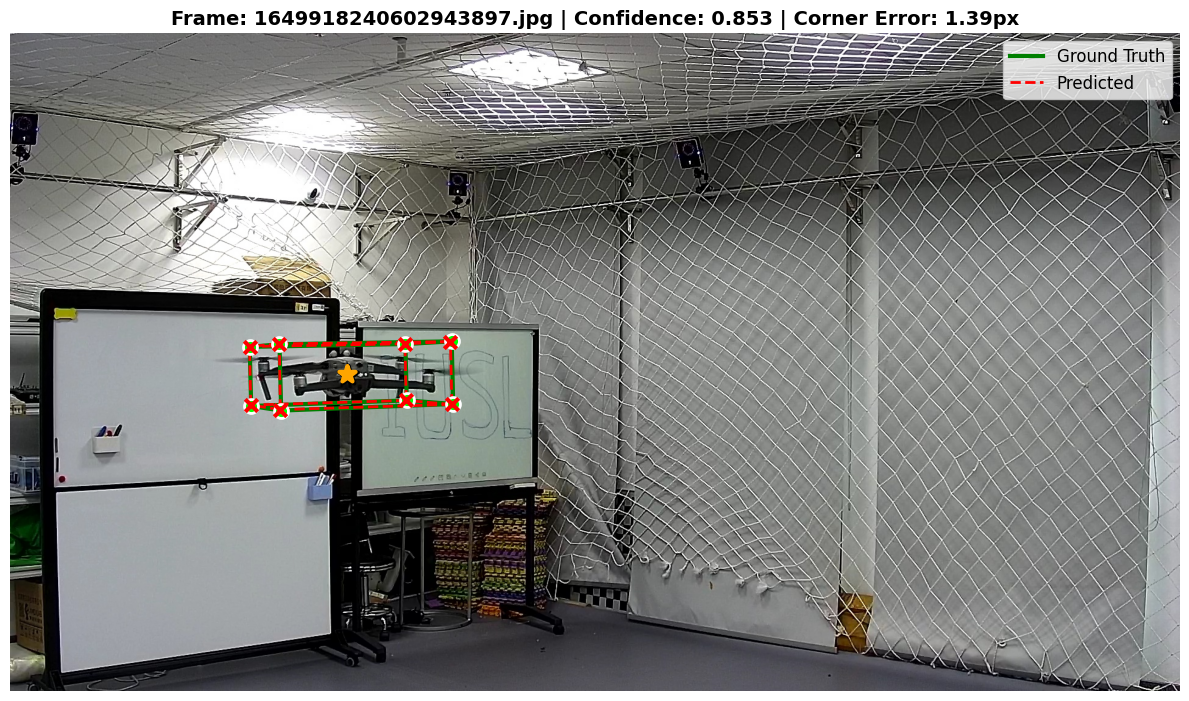

In [9]:
# YOLO6D SINGLE-FRAME PREDICTION vs GROUND-TRUTH VISUALIZER
#
# PURPOSE:
#   Run YOLOv5-6D-Pose inference on the first frame of the first sequence
#   in folder "02", overlay predicted and ground-truth 3D bounding box corners
#   on the image, and save/display the result for visual sanity-checking.
#
# PIPELINE:
#   image → letterbox resize → YOLOv5-6D inference → 9 keypoints (pixels)
#   label → parse normalized coords → undo letterbox → original image pixels
#   both sets of corners → draw 3D bbox wireframe edges → save PNG
#
# DATA STRUCTURES:
#   gt_norm:      (18,) float — centroid + 8 corners as x0,y0,x1,y1,...
#                 normalized to [0,1] relative to unpadded image area
#   pred_pixels:  (9, 2) float — [centroid, corner1..corner8] in original image pixels
#   gt_pixels:    (9, 2) float — same layout, from label
#   edges:        list of 12 [i,j] pairs — 3D bounding box wireframe topology
#                 indices are 0-based into the 8 corners (centroid excluded)
#   label format: class x0 y0 x1 y1 ... x8 y8 [extra...]
#                 indices 1–18 = centroid + 8 corners, normalized 0–1
#
# INPUT DIRECTORY LAYOUT (EXPECTED):
#   DATA_DIR/
#     JPEGImages/02/<seq_dir>/*.jpg   — image sequences
#     labels_yolo6d/02/<seq_dir>/*.txt — matching YOLO6D labels (same relative path)
#   WEIGHTS: exp40/weights/best.pt
#
# DOES:
#   - Picks first sequence in JPEGImages/02/, first frame in that sequence
#   - Loads matching label from labels_yolo6d/ (mirror path, .txt extension)
#   - Runs YOLOv5-6D inference (conf_thresh=0.01), takes top detection
#   - Rescales both predicted and GT corners from letterbox space → original image
#   - Draws 12-edge wireframe for GT (green solid) and prediction (red dashed)
#   - Marks corners (GT=lime circles, pred=red crosses) and centroids (stars)
#   - Annotates title with filename, confidence, and mean corner error (pixels)
#   - Saves to first_frame_debug.png (150 dpi) and shows via plt.show()
#
# OUTPUT:
#   first_frame_debug.png — annotated overlay image
#   Console: image path, label path, letterbox params, confidence,
#            per-centroid coords + diff, mean corner error
#
# DEPENDENCIES:
#   numpy, opencv, torch, matplotlib
#   YOLOv5-6D-Pose repo (models.experimental, utils.{datasets,general,pose_utils,torch_utils})
#
# NOTES:
#   - Corner error is mean L2 over the 8 box corners (index 1–8); centroid excluded.
#   - Edge list uses 0-based corner indices; +1 offset applied when indexing into
#     the (9,2) arrays to skip the centroid at index 0.
#   - Letterbox undo: normalized coords × unpadded dims + pad offset → scale_coords.

import numpy as np
import sys
from pathlib import Path
import cv2
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))

from models.experimental import attempt_load
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.general import check_img_size, scale_coords
from utils.pose_utils import box_filter

# ============================================================================
# SETUP
# ============================================================================

DATA_DIR = Path.home() / 'Desktop/YOLOv5-6D-Pose/data/data/mavic2'
WEIGHTS = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train/exp4/weights/best.pt')

# Find first sequence in folder 02
folder_02 = DATA_DIR / 'JPEGImages' / '02'
sequences = sorted([d for d in folder_02.iterdir() if d.is_dir()])
test_sequence = sequences[0]

# Get first image
image_files = sorted(test_sequence.glob('*.jpg'))
image_path = image_files[0]

print(f"Processing: {image_path.relative_to(DATA_DIR)}")

# Find corresponding YOLO label (GT corners)
rel_path = image_path.relative_to(DATA_DIR / 'JPEGImages')
yolo_label_path = DATA_DIR / 'labels_yolo6d' / rel_path.with_suffix('.txt')

print(f"YOLO label: {yolo_label_path.relative_to(DATA_DIR)}")
print(f"Exists: {yolo_label_path.exists()}")

if not yolo_label_path.exists():
    print("ERROR: YOLO label not found!")
    sys.exit(1)

# ============================================================================
# LOAD GT CORNERS FROM YOLO LABEL
# ============================================================================

with open(yolo_label_path) as f:
    label_data = [float(x) for x in f.readline().strip().split()]

print(f"\nLabel has {len(label_data)} values")
print(f"Label format: class + 9 keypoints (centroid + 8 corners), normalized 0-1")

# Extract GT corners (indices 1-18: centroid + 8 corners, normalized)
gt_norm = np.array([label_data[i] for i in range(1, 19)])

# ============================================================================
# LOAD IMAGE AND GET PREDICTION
# ============================================================================

# Load image
img0 = cv2.imread(str(image_path))
h0, w0 = img0.shape[:2]
print(f"\nImage size: {w0}x{h0}")

# Load model
device = select_device('cpu')
model = attempt_load(WEIGHTS, map_location=device)
model.eval()

# Prepare image
stride = int(model.stride.max())
img_size = check_img_size(640, s=stride)

img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
shape = (h0, w0)
shapes = ((h0, w0), (ratio, pad))

print(f"Letterbox: {img.shape[1]}x{img.shape[0]}, ratio={ratio}, pad={pad}")

# To tensor
img_tensor = img[:, :, ::-1].transpose(2, 0, 1)
img_tensor = np.ascontiguousarray(img_tensor)
img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
if img_tensor.ndimension() == 3:
    img_tensor = img_tensor.unsqueeze(0)

# Inference
with torch.no_grad():
    pred, _ = model(img_tensor)

pred = box_filter(pred, conf_thres=0.01, max_det=10)

if pred is None or len(pred) == 0 or len(pred[0]) == 0:
    print("ERROR: No detections!")
    sys.exit(1)

det = pred[0][0].clone().cpu()
confidence = float(det[18])
corners_pred = det[:18].reshape(1, 18)

# Scale predictions to original image space
scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
pred_pixels = corners_pred[0].numpy().reshape(9, 2)

print(f"\n✓ Prediction successful (confidence: {confidence:.3f})")

# ============================================================================
# SCALE GT CORNERS TO ORIGINAL IMAGE SPACE
# ============================================================================

# Get letterbox dimensions
_, _, height, width = img_tensor.shape

# Labels are normalized to unpadded image area
unpadded_w = width - 2 * pad[0]
unpadded_h = height - 2 * pad[1]

# Scale by unpadded dimensions
gt_letterbox = gt_norm.copy()
gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w  # x coords
gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h  # y coords

# Add padding offset
gt_letterbox[::2] += pad[0]  # x offset
gt_letterbox[1::2] += pad[1]  # y offset

# Scale to original image space
gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])

gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)

# ============================================================================
# VISUALIZE
# ============================================================================

# 3D bounding box edges
edges = [[0,1],[0,2],[0,4],[1,3],[1,5],[2,3],[2,6],[3,7],[4,5],[4,6],[5,7],[6,7]]

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Show image
img_rgb = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)
ax.imshow(img_rgb)

# Draw GT (green)
for i, edge in enumerate(edges):
    ax.plot([gt_pixels[edge[0]+1, 0], gt_pixels[edge[1]+1, 0]], 
            [gt_pixels[edge[0]+1, 1], gt_pixels[edge[1]+1, 1]], 
            'g-', linewidth=3, label='Ground Truth' if i==0 else '')
ax.scatter(gt_pixels[1:, 0], gt_pixels[1:, 1], c='lime', s=100, 
          edgecolors='white', linewidths=2, zorder=5)
ax.scatter(gt_pixels[0, 0], gt_pixels[0, 1], c='lime', s=200, 
          marker='*', edgecolors='black', linewidths=3, zorder=5)

# Draw Pred (red)
for i, edge in enumerate(edges):
    ax.plot([pred_pixels[edge[0]+1, 0], pred_pixels[edge[1]+1, 0]], 
            [pred_pixels[edge[0]+1, 1], pred_pixels[edge[1]+1, 1]], 
            'r-', linewidth=2, linestyle='--', label='Predicted' if i==0 else '')
ax.scatter(pred_pixels[1:, 0], pred_pixels[1:, 1], c='red', s=80, 
          marker='x', linewidths=3, zorder=5)
ax.scatter(pred_pixels[0, 0], pred_pixels[0, 1], c='orange', s=150, 
          marker='*', linewidths=3, zorder=5)

# Compute error
corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))

ax.set_title(f"Frame: {image_path.name} | Confidence: {confidence:.3f} | Corner Error: {corner_error:.2f}px", 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig('first_frame_debug.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: first_frame_debug.png")
print(f"\nCorner error: {corner_error:.2f} pixels")
print(f"Centroid GT:   {gt_pixels[0]}")
print(f"Centroid Pred: {pred_pixels[0]}")
print(f"Centroid diff: {np.linalg.norm(pred_pixels[0] - gt_pixels[0]):.2f} pixels")

plt.show()

In [10]:
"""
Create video of full sequence showing predicted vs GT corners
"""

import numpy as np
import sys
from pathlib import Path
import cv2
import torch
from tqdm import tqdm

sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))

from models.experimental import attempt_load
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.general import check_img_size, scale_coords
from utils.pose_utils import box_filter

# ============================================================================
# SETUP
# ============================================================================

DATA_DIR = Path.home() / 'Desktop/YOLOv5-6D-Pose/data/data/mavic2'
WEIGHTS = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train/exp4/weights/best.pt')
OUTPUT_VIDEO = 'sequence_visualization.mp4'

# Find first sequence in folder 02
folder_02 = DATA_DIR / 'JPEGImages' / '02'
sequences = sorted([d for d in folder_02.iterdir() if d.is_dir()])
test_sequence = sequences[0]

print(f"Processing sequence: {test_sequence.name}")

# Get all images
image_files = sorted(test_sequence.glob('*.jpg'))
print(f"Found {len(image_files)} images")

# Load model
device = select_device('cpu')
model = attempt_load(WEIGHTS, map_location=device)
model.eval()
print("✓ Model loaded\n")

# 3D bounding box edges (skip centroid at index 0)
edges = [[0,1],[0,2],[0,4],[1,3],[1,5],[2,3],[2,6],[3,7],[4,5],[4,6],[5,7],[6,7]]

# Get first image to determine video size
first_img = cv2.imread(str(image_files[0]))
h0, w0 = first_img.shape[:2]

# Setup video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 30.0, (w0, h0))

stride = int(model.stride.max())
img_size = check_img_size(640, s=stride)

# Process all frames
for img_path in tqdm(image_files, desc="Creating video"):
    
    # Find corresponding YOLO label (GT corners)
    rel_path = img_path.relative_to(DATA_DIR / 'JPEGImages')
    yolo_label_path = DATA_DIR / 'labels_yolo6d' / rel_path.with_suffix('.txt')
    
    if not yolo_label_path.exists():
        continue
    
    # Load GT corners
    with open(yolo_label_path) as f:
        label_data = [float(x) for x in f.readline().strip().split()]
    
    gt_norm = np.array([label_data[i] for i in range(1, 19)])
    
    # Load image
    img0 = cv2.imread(str(img_path))
    if img0 is None:
        continue
    
    h0, w0 = img0.shape[:2]
    
    # Prepare image for model
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shape = (h0, w0)
    shapes = ((h0, w0), (ratio, pad))
    
    # To tensor
    img_tensor = img[:, :, ::-1].transpose(2, 0, 1)
    img_tensor = np.ascontiguousarray(img_tensor)
    img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
    if img_tensor.ndimension() == 3:
        img_tensor = img_tensor.unsqueeze(0)
    
    # Inference
    with torch.no_grad():
        pred, _ = model(img_tensor)
    
    pred = box_filter(pred, conf_thres=0.01, max_det=10)
    
    # Get prediction
    if pred is not None and len(pred) > 0 and len(pred[0]) > 0:
        det = pred[0][0].clone().cpu()
        confidence = float(det[18])
        corners_pred = det[:18].reshape(1, 18)
        
        # Scale predictions to original image space
        scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
        pred_pixels = corners_pred[0].numpy().reshape(9, 2)
    else:
        # No detection - skip this frame
        continue
    
    # Scale GT corners to original image space
    _, _, height, width = img_tensor.shape
    unpadded_w = width - 2 * pad[0]
    unpadded_h = height - 2 * pad[1]
    
    gt_letterbox = gt_norm.copy()
    gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w + pad[0]
    gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h + pad[1]
    
    gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
    scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])
    gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)
    
    # Compute error
    corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))
    
    # Draw on frame
    frame = img0.copy()
    
    # Draw GT (green) - skip centroid
    for edge in edges:
        pt1 = (int(gt_pixels[edge[0]+1, 0]), int(gt_pixels[edge[0]+1, 1]))
        pt2 = (int(gt_pixels[edge[1]+1, 0]), int(gt_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 255, 0), 1)  # Thin green line
    
    # Draw GT corner points
    for i in range(1, 9):
        pt = (int(gt_pixels[i, 0]), int(gt_pixels[i, 1]))
        cv2.circle(frame, pt, 4, (0, 255, 0), -1)
    
    # Draw Pred (red) - skip centroid
    for edge in edges:
        pt1 = (int(pred_pixels[edge[0]+1, 0]), int(pred_pixels[edge[0]+1, 1]))
        pt2 = (int(pred_pixels[edge[1]+1, 0]), int(pred_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 0, 255), 1)  # Thin red line
    
    # Draw Pred corner points
    for i in range(1, 9):
        pt = (int(pred_pixels[i, 0]), int(pred_pixels[i, 1]))
        cv2.circle(frame, pt, 3, (0, 0, 255), -1)
    
    # Add text overlay
    cv2.putText(frame, f"Frame: {img_path.name}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Confidence: {confidence:.3f}", (10, 60), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Error: {corner_error:.2f}px", (10, 90), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, "Green: GT | Red: Pred", (10, h0-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    # Write frame
    out.write(frame)

# Release video writer
out.release()

print(f"\n✓ Video saved: {OUTPUT_VIDEO}")
print(f"  Frames: {len(image_files)}")
print(f"  Resolution: {w0}x{h0}")
print(f"  FPS: 30")

Processing sequence: 0201
Found 304 images
✓ Model loaded



Creating video: 100%|██████████| 304/304 [12:04<00:00,  2.38s/it]


✓ Video saved: sequence_visualization.mp4
  Frames: 304
  Resolution: 1920x1080
  FPS: 30


In [12]:
"""
Create video of full sequence showing predicted vs GT corners
"""

import numpy as np
import sys
from pathlib import Path
import cv2
import torch
from tqdm import tqdm

sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))

from models.experimental import attempt_load
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.general import check_img_size, scale_coords
from utils.pose_utils import box_filter

# ============================================================================
# SETUP
# ============================================================================

DATA_DIR = Path.home() / 'Desktop/YOLOv5-6D-Pose/data/data/mavic2'
WEIGHTS = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train/exp7/weights/best.pt')
OUTPUT_VIDEO = 'sequence_visualization.mp4'

# Find first sequence in folder 02
folder_02 = DATA_DIR / 'JPEGImages' / '02'
sequences = sorted([d for d in folder_02.iterdir() if d.is_dir()])
test_sequence = sequences[0]

print(f"Processing sequence: {test_sequence.name}")

# Get all images
image_files = sorted(test_sequence.glob('*.jpg'))
print(f"Found {len(image_files)} images")

# Load model
device = select_device('cpu')
model = attempt_load(WEIGHTS, map_location=device)
model.eval()
print("✓ Model loaded\n")

# 3D bounding box edges (skip centroid at index 0)
edges = [[0,1],[0,2],[0,4],[1,3],[1,5],[2,3],[2,6],[3,7],[4,5],[4,6],[5,7],[6,7]]

# Get first image to determine video size
first_img = cv2.imread(str(image_files[0]))
h0, w0 = first_img.shape[:2]

# Setup video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 30.0, (w0, h0))

if not out.isOpened():
    print("ERROR: Failed to open video writer!")
    print(f"Trying alternative codec...")
    # Try alternative codec
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    OUTPUT_VIDEO = 'sequence_visualization.avi'
    out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, 30.0, (w0, h0))
    
    if not out.isOpened():
        print("ERROR: Video writer still failed!")
        sys.exit(1)

print(f"✓ Video writer initialized: {w0}x{h0} @ 30fps")

stride = int(model.stride.max())
img_size = check_img_size(640, s=stride)

# Process all frames
frames_written = 0
for img_path in tqdm(image_files, desc="Creating video"):
    
    # Find corresponding YOLO label (GT corners)
    rel_path = img_path.relative_to(DATA_DIR / 'JPEGImages')
    yolo_label_path = DATA_DIR / 'labels_yolo6d' / rel_path.with_suffix('.txt')
    
    if not yolo_label_path.exists():
        continue
    
    # Load GT corners
    with open(yolo_label_path) as f:
        label_data = [float(x) for x in f.readline().strip().split()]
    
    gt_norm = np.array([label_data[i] for i in range(1, 19)])
    
    # Load image
    img0 = cv2.imread(str(img_path))
    if img0 is None:
        continue
    
    h0, w0 = img0.shape[:2]
    
    # Prepare image for model
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shape = (h0, w0)
    shapes = ((h0, w0), (ratio, pad))
    
    # To tensor
    img_tensor = img[:, :, ::-1].transpose(2, 0, 1)
    img_tensor = np.ascontiguousarray(img_tensor)
    img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
    if img_tensor.ndimension() == 3:
        img_tensor = img_tensor.unsqueeze(0)
    
    # Inference
    with torch.no_grad():
        pred, _ = model(img_tensor)
    
    pred = box_filter(pred, conf_thres=0.01, max_det=10)
    
    # Get prediction
    if pred is not None and len(pred) > 0 and len(pred[0]) > 0:
        det = pred[0][0].clone().cpu()
        confidence = float(det[18])
        corners_pred = det[:18].reshape(1, 18)
        
        # Scale predictions to original image space
        scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
        pred_pixels = corners_pred[0].numpy().reshape(9, 2)
    else:
        # No detection - skip this frame
        continue
    
    # Scale GT corners to original image space
    _, _, height, width = img_tensor.shape
    unpadded_w = width - 2 * pad[0]
    unpadded_h = height - 2 * pad[1]
    
    gt_letterbox = gt_norm.copy()
    gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w + pad[0]
    gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h + pad[1]
    
    gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
    scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])
    gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)
    
    # Compute error
    corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))
    
    # Draw on frame
    frame = img0.copy()
    
    # Draw GT (green) - skip centroid
    for edge in edges:
        pt1 = (int(gt_pixels[edge[0]+1, 0]), int(gt_pixels[edge[0]+1, 1]))
        pt2 = (int(gt_pixels[edge[1]+1, 0]), int(gt_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 255, 0), 1)  # Thin green line
    
    # Draw GT corner points
    for i in range(1, 9):
        pt = (int(gt_pixels[i, 0]), int(gt_pixels[i, 1]))
        cv2.circle(frame, pt, 4, (0, 255, 0), -1)
    
    # Draw Pred (red) - skip centroid
    for edge in edges:
        pt1 = (int(pred_pixels[edge[0]+1, 0]), int(pred_pixels[edge[0]+1, 1]))
        pt2 = (int(pred_pixels[edge[1]+1, 0]), int(pred_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 0, 255), 1)  # Thin red line
    
    # Draw Pred corner points
    for i in range(1, 9):
        pt = (int(pred_pixels[i, 0]), int(pred_pixels[i, 1]))
        cv2.circle(frame, pt, 3, (0, 0, 255), -1)
    
    # Add text overlay
    cv2.putText(frame, f"Frame: {img_path.name}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Confidence: {confidence:.3f}", (10, 60), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Error: {corner_error:.2f}px", (10, 90), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, "Green: GT | Red: Pred", (10, h0-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    # Write frame
    out.write(frame)
    frames_written += 1

# Release video writer
out.release()

print(f"\n✓ Video saved: {OUTPUT_VIDEO}")
print(f"  Total images: {len(image_files)}")
print(f"  Frames written: {frames_written}")
print(f"  Resolution: {w0}x{h0}")
print(f"  FPS: 30")

if frames_written == 0:
    print("\nWARNING: No frames were written to video!")
else:
    # Verify the video file exists and has size > 0
    video_path = Path(OUTPUT_VIDEO)
    if video_path.exists():
        size_mb = video_path.stat().st_size / (1024 * 1024)
        print(f"  File size: {size_mb:.2f} MB")
        
        if size_mb < 0.1:
            print("  WARNING: Video file is very small, may be corrupted")
    else:
        print("  ERROR: Video file was not created!")

Processing sequence: 0201
Found 304 images
✓ Model loaded

✓ Video writer initialized: 1920x1080 @ 30fps


Creating video: 100%|██████████| 304/304 [03:59<00:00,  1.27it/s]


✓ Video saved: sequence_visualization.mp4
  Total images: 304
  Frames written: 304
  Resolution: 1920x1080
  FPS: 30
  File size: 30.91 MB


In [ ]:
"""
Create video by saving frames then using ffmpeg (more reliable)
"""

import numpy as np
import syssshfs pliskmic@login3.rci.cvut.cz:/mnt/personal/pliskmic ~/rci_cluster
from pathlib import Path
import cv2
import torch
from tqdm import tqdm
import subprocess
import shutil

sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))

from models.experimental import attempt_load
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.general import check_img_size, scale_coords
from utils.pose_utils import box_filter

# ============================================================================
# SETUP
# ============================================================================

DATA_DIR = Path.home() / 'Desktop/YOLOv5-6D-Pose/data/data/phantom4'
WEIGHTS = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train/exp40/weights/best.pt')
FRAMES_DIR = Path('video_frames')
OUTPUT_VIDEO = 'sequence_final.mp4'

# Create frames directory
if FRAMES_DIR.exists():
    shutil.rmtree(FRAMES_DIR)
FRAMES_DIR.mkdir()

# Find first sequence in folder 02
folder_02 = DATA_DIR / 'JPEGImages' / '02'
sequences = sorted([d for d in folder_02.iterdir() if d.is_dir()])
test_sequence = sequences[0]

print(f"Processing sequence: {test_sequence.name}")

# Get all images
image_files = sorted(test_sequence.glob('*.jpg'))
print(f"Found {len(image_files)} images")

# Load model
device = select_device('cpu')
model = attempt_load(WEIGHTS, map_location=device)
model.eval()
print("✓ Model loaded\n")

# 3D bounding box edges (skip centroid at index 0)
edges = [[0,1],[0,2],[0,4],[1,3],[1,5],[2,3],[2,6],[3,7],[4,5],[4,6],[5,7],[6,7]]

stride = int(model.stride.max())
img_size = check_img_size(640, s=stride)

# Process all frames
frame_num = 0

for img_path in tqdm(image_files, desc="Processing frames"):
    
    # Find corresponding YOLO label (GT corners)
    rel_path = img_path.relative_to(DATA_DIR / 'JPEGImages')
    yolo_label_path = DATA_DIR / 'labels_yolo6d' / rel_path.with_suffix('.txt')
    
    if not yolo_label_path.exists():
        continue
    
    # Load GT corners
    with open(yolo_label_path) as f:
        label_data = [float(x) for x in f.readline().strip().split()]
    
    gt_norm = np.array([label_data[i] for i in range(1, 19)])
    
    # Load image
    img0 = cv2.imread(str(img_path))
    if img0 is None:
        continue
    
    h0, w0 = img0.shape[:2]
    
    # Prepare image for model
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shape = (h0, w0)
    shapes = ((h0, w0), (ratio, pad))
    
    # To tensor
    img_tensor = img[:, :, ::-1].transpose(2, 0, 1)
    img_tensor = np.ascontiguousarray(img_tensor)
    img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
    if img_tensor.ndimension() == 3:
        img_tensor = img_tensor.unsqueeze(0)
    
    # Inference
    with torch.no_grad():
        pred, _ = model(img_tensor)
    
    pred = box_filter(pred, conf_thres=0.01, max_det=10)
    
    # Get prediction
    if pred is not None and len(pred) > 0 and len(pred[0]) > 0:
        det = pred[0][0].clone().cpu()
        confidence = float(det[18])
        corners_pred = det[:18].reshape(1, 18)
        
        # Scale predictions to original image space
        scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
        pred_pixels = corners_pred[0].numpy().reshape(9, 2)
    else:
        # No detection - skip this frame
        continue
    
    # Scale GT corners to original image space
    _, _, height, width = img_tensor.shape
    unpadded_w = width - 2 * pad[0]
    unpadded_h = height - 2 * pad[1]
    
    gt_letterbox = gt_norm.copy()
    gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w + pad[0]
    gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h + pad[1]
    
    gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
    scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])
    gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)
    
    # Compute error
    corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))
    
    # Draw on frame
    frame = img0.copy()
    
    # Draw GT (green) - skip centroid
    for edge in edges:
        pt1 = (int(gt_pixels[edge[0]+1, 0]), int(gt_pixels[edge[0]+1, 1]))
        pt2 = (int(gt_pixels[edge[1]+1, 0]), int(gt_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 255, 0), 1)
    
    for i in range(1, 9):
        pt = (int(gt_pixels[i, 0]), int(gt_pixels[i, 1]))
        cv2.circle(frame, pt, 4, (0, 255, 0), -1)
    
    # Draw Pred (red) - skip centroid
    for edge in edges:
        pt1 = (int(pred_pixels[edge[0]+1, 0]), int(pred_pixels[edge[0]+1, 1]))
        pt2 = (int(pred_pixels[edge[1]+1, 0]), int(pred_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 0, 255), 1)
    
    for i in range(1, 9):
        pt = (int(pred_pixels[i, 0]), int(pred_pixels[i, 1]))
        cv2.circle(frame, pt, 3, (0, 0, 255), -1)
    
    # Add text overlay
    cv2.putText(frame, f"Frame: {img_path.name}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Confidence: {confidence:.3f}", (10, 60), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Error: {corner_error:.2f}px", (10, 90), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, "Green: GT | Red: Pred", (10, h0-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    # Save frame
    frame_filename = FRAMES_DIR / f"frame_{frame_num:05d}.jpg"
    cv2.imwrite(str(frame_filename), frame)
    frame_num += 1

print(f"\n✓ Saved {frame_num} frames to {FRAMES_DIR}/")

# Create video with ffmpeg
if frame_num > 0:
    print("\nCreating video with ffmpeg...")
    
    cmd = [
        'ffmpeg', '-y',
        '-framerate', '30',
        '-i', str(FRAMES_DIR / 'frame_%05d.jpg'),
        '-c:v', 'libx264',
        '-preset', 'medium',
        '-crf', '23',
        '-pix_fmt', 'yuv420p',
        OUTPUT_VIDEO
    ]
    
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
        
        if result.returncode == 0:
            output_path = Path(OUTPUT_VIDEO)
            if output_path.exists():
                size_mb = output_path.stat().st_size / (1024 * 1024)
                print(f"\n✓ Video created: {OUTPUT_VIDEO}")
                print(f"  Frames: {frame_num}")
                print(f"  Size: {size_mb:.2f} MB")
                print(f"  FPS: 30")
                
                # Clean up frames directory
                print(f"\nCleaning up temporary frames...")
                shutil.rmtree(FRAMES_DIR)
                print(f"✓ Done!")
            else:
                print("ERROR: Video file not created")
        else:
            print(f"ERROR: ffmpeg failed")
            print(result.stderr)
    
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("\nERROR: No frames were created!")

In [ ]:
"""
Create video by saving frames then using ffmpeg (more reliable)
"""

import numpy as np
import sys
from pathlib import Path
import cv2
import torch
from tqdm import tqdm
import subprocess
import shutil

sys.path.insert(0, str(Path.home() / 'git/YOLOv5-6D-Pose'))

from models.experimental import attempt_load
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.general import check_img_size, scale_coords
from utils.pose_utils import box_filter

# ============================================================================
# SETUP
# ============================================================================

DATA_DIR = Path.home() / 'Desktop/YOLOv5-6D-Pose/data/data/phantom4'
WEIGHTS = str(Path.home() / 'Desktop/YOLOv5-6D-Pose/runs/train/exp40/weights/best.pt')
FRAMES_DIR = Path('video_frames')
OUTPUT_VIDEO = 'sequence_final.mp4'

# Create frames directory
if FRAMES_DIR.exists():
    shutil.rmtree(FRAMES_DIR)
FRAMES_DIR.mkdir()

# Find first sequence in folder 02
folder_02 = DATA_DIR / 'JPEGImages' / '02'
sequences = sorted([d for d in folder_02.iterdir() if d.is_dir()])
test_sequence = sequences[0]

print(f"Processing sequence: {test_sequence.name}")

# Get all images
image_files = sorted(test_sequence.glob('*.jpg'))
print(f"Found {len(image_files)} images")

# Load model
device = select_device('cpu')
model = attempt_load(WEIGHTS, map_location=device)
model.eval()
print("✓ Model loaded\n")

# 3D bounding box edges (skip centroid at index 0)
edges = [[0,1],[0,2],[0,4],[1,3],[1,5],[2,3],[2,6],[3,7],[4,5],[4,6],[5,7],[6,7]]

stride = int(model.stride.max())
img_size = check_img_size(640, s=stride)

# Process all frames
frames_saved = []

for img_path in tqdm(image_files, desc="Processing frames"):
    
    # Find corresponding YOLO label (GT corners)
    rel_path = img_path.relative_to(DATA_DIR / 'JPEGImages')
    yolo_label_path = DATA_DIR / 'labels_yolo6d' / rel_path.with_suffix('.txt')
    
    if not yolo_label_path.exists():
        continue
    
    # Load GT corners
    with open(yolo_label_path) as f:
        label_data = [float(x) for x in f.readline().strip().split()]
    
    gt_norm = np.array([label_data[i] for i in range(1, 19)])
    
    # Load image
    img0 = cv2.imread(str(img_path))
    if img0 is None:
        continue
    
    h0, w0 = img0.shape[:2]
    
    # Prepare image for model
    img, ratio, pad = letterbox(img0, img_size, stride=stride, auto=False)
    shape = (h0, w0)
    shapes = ((h0, w0), (ratio, pad))
    
    # To tensor
    img_tensor = img[:, :, ::-1].transpose(2, 0, 1)
    img_tensor = np.ascontiguousarray(img_tensor)
    img_tensor = torch.from_numpy(img_tensor).to(device).float() / 255.0
    if img_tensor.ndimension() == 3:
        img_tensor = img_tensor.unsqueeze(0)
    
    # Inference
    with torch.no_grad():
        pred, _ = model(img_tensor)
    
    pred = box_filter(pred, conf_thres=0.01, max_det=10)
    
    # Get prediction
    if pred is not None and len(pred) > 0 and len(pred[0]) > 0:
        det = pred[0][0].clone().cpu()
        confidence = float(det[18])
        corners_pred = det[:18].reshape(1, 18)
        
        # Scale predictions to original image space
        scale_coords(img_tensor.shape[2:], corners_pred, shape, shapes[1])
        pred_pixels = corners_pred[0].numpy().reshape(9, 2)
    else:
        # No detection - skip this frame
        continue
    
    # Scale GT corners to original image space
    _, _, height, width = img_tensor.shape
    unpadded_w = width - 2 * pad[0]
    unpadded_h = height - 2 * pad[1]
    
    gt_letterbox = gt_norm.copy()
    gt_letterbox[::2] = gt_letterbox[::2] * unpadded_w + pad[0]
    gt_letterbox[1::2] = gt_letterbox[1::2] * unpadded_h + pad[1]
    
    gt_letterbox_tensor = torch.from_numpy(gt_letterbox).reshape(1, 18).float()
    scale_coords(img_tensor.shape[2:], gt_letterbox_tensor, shape, shapes[1])
    gt_pixels = gt_letterbox_tensor[0].numpy().reshape(9, 2)
    
    # Compute error
    corner_error = np.mean(np.linalg.norm(pred_pixels[1:] - gt_pixels[1:], axis=1))
    
    # Draw on frame
    frame = img0.copy()
    
    # Draw GT (green) - skip centroid
    for edge in edges:
        pt1 = (int(gt_pixels[edge[0]+1, 0]), int(gt_pixels[edge[0]+1, 1]))
        pt2 = (int(gt_pixels[edge[1]+1, 0]), int(gt_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 255, 0), 1)
    
    for i in range(1, 9):
        pt = (int(gt_pixels[i, 0]), int(gt_pixels[i, 1]))
        cv2.circle(frame, pt, 4, (0, 255, 0), -1)
    
    # Draw Pred (red) - skip centroid
    for edge in edges:
        pt1 = (int(pred_pixels[edge[0]+1, 0]), int(pred_pixels[edge[0]+1, 1]))
        pt2 = (int(pred_pixels[edge[1]+1, 0]), int(pred_pixels[edge[1]+1, 1]))
        cv2.line(frame, pt1, pt2, (0, 0, 255), 1)
    
    for i in range(1, 9):
        pt = (int(pred_pixels[i, 0]), int(pred_pixels[i, 1]))
        cv2.circle(frame, pt, 3, (0, 0, 255), -1)
    
    # Add text overlay
    cv2.putText(frame, f"Frame: {img_path.name}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Confidence: {confidence:.3f}", (10, 60), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Error: {corner_error:.2f}px", (10, 90), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, "Green: GT | Red: Pred", (10, h0-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    # Save frame with sequential numbering
    frame_filename = FRAMES_DIR / f"frame_{len(frames_saved):05d}.jpg"
    cv2.imwrite(str(frame_filename), frame)
    frames_saved.append(frame_filename)

print(f"\n✓ Saved {len(frames_saved)} frames to {FRAMES_DIR}/")

# Create video with ffmpeg
if len(frames_saved) > 0:
    print("\nCreating video with ffmpeg...")
    
    cmd = [
        'ffmpeg', '-y',
        '-framerate', '30',
        '-i', str(FRAMES_DIR / 'frame_%05d.jpg'),
        '-c:v', 'libx264',
        '-preset', 'medium',
        '-crf', '23',
        '-pix_fmt', 'yuv420p',
        OUTPUT_VIDEO
    ]
    
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
        
        if result.returncode == 0:
            output_path = Path(OUTPUT_VIDEO)
            if output_path.exists():
                size_mb = output_path.stat().st_size / (1024 * 1024)
                print(f"\n✓ Video created: {OUTPUT_VIDEO}")
                print(f"  Frames: {len(frames_saved)}")
                print(f"  Size: {size_mb:.2f} MB")
                print(f"  FPS: 30")
                
                # Clean up frames directory
                print(f"\nCleaning up temporary frames...")
                shutil.rmtree(FRAMES_DIR)
                print(f"✓ Done!")
            else:
                print("ERROR: Video file not created")
        else:
            print(f"ERROR: ffmpeg failed")
            print(result.stderr)
    
    except Exception as e:
        print(f"ERROR: {e}")
else:
    print("\nERROR: No frames were created!")